**Script Ptyhon**


In [6]:
import redis
import json
import time

try:
    # Usamos decode_responses=True para obtener strings de texto en lugar de bytes
    r = redis.Redis(host='localhost', port=6379, db=0, decode_responses=True)
    r.ping()
    print("Conexión a Redis establecida con éxito.")
except Exception as e:
    print(f"Error al conectar con Redis: {e}")
    exit()

# La clave de Redis que usaremos como cola
COLA_PEDIDOS = 'pedidos'

# Inicializador de ID global simple para simular IDs únicos
id_counter = 0

def generar_id_pedido():
    """Genera un ID de pedido simple y lo incrementa."""
    global id_counter
    id_counter += 1
    # Formato simple: 'PEDIDO_001', 'PEDIDO_002', etc.
    return f"PEDIDO_{id_counter:03d}"

def agregar_pedido(cliente: str, producto: str, urgente: bool = False):
    id_pedido = generar_id_pedido()
    
    pedido = {
        "id": id_pedido,
        "cliente": cliente,
        "producto": producto,
        "cantidad": 1,
        "urgente": urgente,
        "timestamp": time.time()
    }
    
    # Convertir el diccionario de Python a una cadena JSON
    pedido_json = json.dumps(pedido)
    
    if urgente:
        # Usamos LPUSH para que se procese primero (frente de la cola)
        r.lpush(COLA_PEDIDOS, pedido_json)
        print(f"-> Pedido URGENTE {id_pedido} de {cliente} añadido a la cola.")
    else:
        # Usamos RPUSH para la cola normal (final de la cola)
        r.rpush(COLA_PEDIDOS, pedido_json)
        print(f"-> Pedido {id_pedido} de {cliente} añadido a la cola.")

def procesar_pedido():
    # LPOP extrae y elimina el elemento del frente (izquierda) de la lista
    pedido_json = r.lpop(COLA_PEDIDOS)
    
    if pedido_json is None:
        print("--- La cola de pedidos está vacía. ---")
        return None
        
    # Convertir la cadena JSON de vuelta a un diccionario de Python
    pedido = json.loads(pedido_json)
    
    tipo = "URGENTE" if pedido.get("urgente") else "NORMAL"
    print(f"\n[PROCESANDO {tipo}] ID: {pedido['id']} | Cliente: {pedido['cliente']} | Producto: {pedido['producto']}")
    return pedido

def mostrar_cola_actual():
    # LRANGE 0 -1 recupera todos los elementos
    pedidos_json = r.lrange(COLA_PEDIDOS, 0, -1)
    
    print(f"\n--- ESTADO ACTUAL DE LA COLA '{COLA_PEDIDOS}' ({len(pedidos_json)} pedidos) ---")
    
    if not pedidos_json:
        print("La cola está vacía.")
        return

    # Mostrar de forma legible (convirtiendo de JSON para la visualización)
    for i, p_json in enumerate(pedidos_json):
        p = json.loads(p_json)
        prioridad = "(URGENTE)" if p.get("urgente") else ""
        # El índice 0 es el HEAD (el próximo a ser procesado)
        print(f"  [{i}] {p['id']} - Cliente: {p['cliente']} {prioridad}")
    print("----------------------------------------------------------")



Conexión a Redis establecida con éxito.


**Realización de la práctica**

**Limpieza de pedidos inicial**

In [7]:
# 1. Limpiamos la cola al inicio para empezar de cero
r.delete(COLA_PEDIDOS)
print(f"\n[INICIO] Cola '{COLA_PEDIDOS}' reseteada.")


[INICIO] Cola 'pedidos' reseteada.


In [8]:
# 2. Inserta 5 pedidos iniciales (RPUSH por defecto)
print("\n[FASE 1: Inserción de 5 pedidos iniciales]")
agregar_pedido("Juan Pérez", "Portátil Lenovo") # ID 1
agregar_pedido("Ana Gómez", "Monitor Curvo 27")  # ID 2
agregar_pedido("Carlos Ruiz", "Teclado Mecánico") # ID 3
agregar_pedido("Laura Soto", "Ratón Ergonómico") # ID 4
agregar_pedido("David Alba", "Webcam HD") # ID 5

# 3. Muestra todos los pedidos actuales en la cola con LRANGE
mostrar_cola_actual()



[FASE 1: Inserción de 5 pedidos iniciales]
-> Pedido PEDIDO_001 de Juan Pérez añadido a la cola.
-> Pedido PEDIDO_002 de Ana Gómez añadido a la cola.
-> Pedido PEDIDO_003 de Carlos Ruiz añadido a la cola.
-> Pedido PEDIDO_004 de Laura Soto añadido a la cola.
-> Pedido PEDIDO_005 de David Alba añadido a la cola.

--- ESTADO ACTUAL DE LA COLA 'pedidos' (5 pedidos) ---
  [0] PEDIDO_001 - Cliente: Juan Pérez 
  [1] PEDIDO_002 - Cliente: Ana Gómez 
  [2] PEDIDO_003 - Cliente: Carlos Ruiz 
  [3] PEDIDO_004 - Cliente: Laura Soto 
  [4] PEDIDO_005 - Cliente: David Alba 
----------------------------------------------------------


**Comprobación**

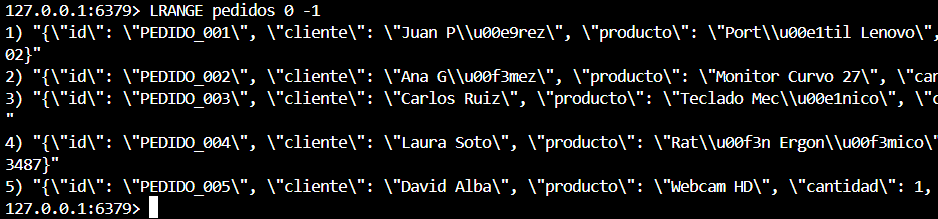

In [9]:
# 4. Inserta 2 pedidos adicionales (simulando nuevos clientes)
print("\n[FASE 2: Inserción de 2 pedidos adicionales]")
agregar_pedido("Elena Cid", "Disco SSD 1TB") # ID 6
agregar_pedido("Felipe Mora", "Tarjeta Gráfica") # ID 7

mostrar_cola_actual()



[FASE 2: Inserción de 2 pedidos adicionales]
-> Pedido PEDIDO_006 de Elena Cid añadido a la cola.
-> Pedido PEDIDO_007 de Felipe Mora añadido a la cola.

--- ESTADO ACTUAL DE LA COLA 'pedidos' (7 pedidos) ---
  [0] PEDIDO_001 - Cliente: Juan Pérez 
  [1] PEDIDO_002 - Cliente: Ana Gómez 
  [2] PEDIDO_003 - Cliente: Carlos Ruiz 
  [3] PEDIDO_004 - Cliente: Laura Soto 
  [4] PEDIDO_005 - Cliente: David Alba 
  [5] PEDIDO_006 - Cliente: Elena Cid 
  [6] PEDIDO_007 - Cliente: Felipe Mora 
----------------------------------------------------------


**Comprobación**


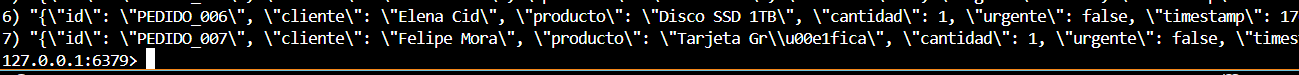

In [10]:
# 5. Procesa todos los pedidos de la cola (7 en total)
print("\n[FASE 3: Procesamiento de todos los pedidos]")
while r.exists(COLA_PEDIDOS):
    pedido = procesar_pedido()
    if not pedido:
        break # Sale si la cola se vacía
        
# 6. Muestra el estado (debería estar vacía)
mostrar_cola_actual()



[FASE 3: Procesamiento de todos los pedidos]

[PROCESANDO NORMAL] ID: PEDIDO_001 | Cliente: Juan Pérez | Producto: Portátil Lenovo

[PROCESANDO NORMAL] ID: PEDIDO_002 | Cliente: Ana Gómez | Producto: Monitor Curvo 27

[PROCESANDO NORMAL] ID: PEDIDO_003 | Cliente: Carlos Ruiz | Producto: Teclado Mecánico

[PROCESANDO NORMAL] ID: PEDIDO_004 | Cliente: Laura Soto | Producto: Ratón Ergonómico

[PROCESANDO NORMAL] ID: PEDIDO_005 | Cliente: David Alba | Producto: Webcam HD

[PROCESANDO NORMAL] ID: PEDIDO_006 | Cliente: Elena Cid | Producto: Disco SSD 1TB

[PROCESANDO NORMAL] ID: PEDIDO_007 | Cliente: Felipe Mora | Producto: Tarjeta Gráfica

--- ESTADO ACTUAL DE LA COLA 'pedidos' (0 pedidos) ---
La cola está vacía.


In [13]:
# 7. Inserta un pedido urgente con LPUSH
print("\n[FASE 4: Inserción y procesamiento de pedido URGENTE]")
agregar_pedido("Gema Cruz", "Servicio VIP", urgente=True) # ID 8

mostrar_cola_actual()



[FASE 4: Inserción y procesamiento de pedido URGENTE]
-> Pedido URGENTE PEDIDO_009 de Gema Cruz añadido a la cola.

--- ESTADO ACTUAL DE LA COLA 'pedidos' (1 pedidos) ---
  [0] PEDIDO_009 - Cliente: Gema Cruz (URGENTE)
----------------------------------------------------------


In [14]:
# 8. Procesa el pedido urgente antes que el resto (solo hay uno)
procesar_pedido()

# 9. Verificación final de limpieza
mostrar_cola_actual()


[PROCESANDO URGENTE] ID: PEDIDO_009 | Cliente: Gema Cruz | Producto: Servicio VIP

--- ESTADO ACTUAL DE LA COLA 'pedidos' (0 pedidos) ---
La cola está vacía.


**Visualización en Redis Insight**

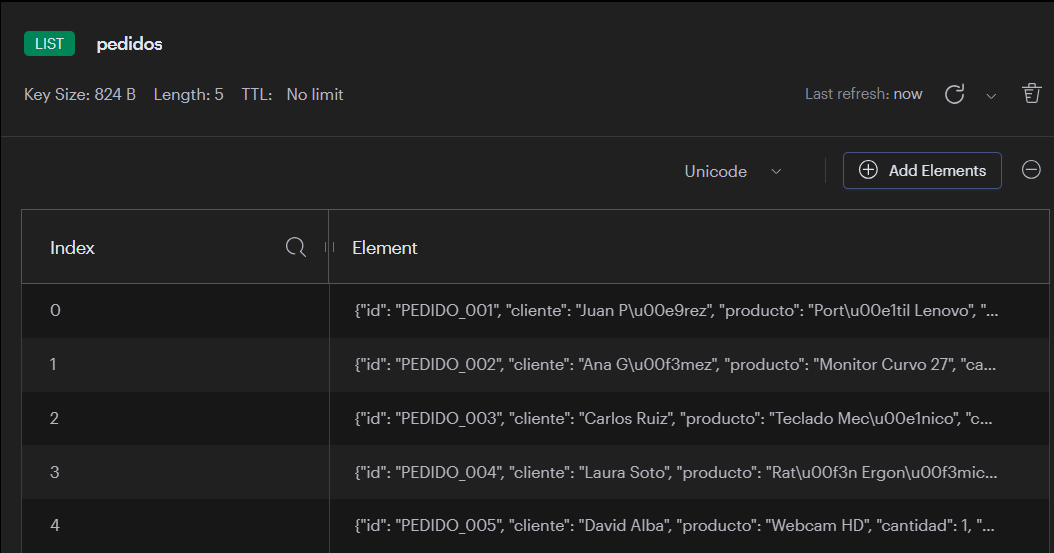

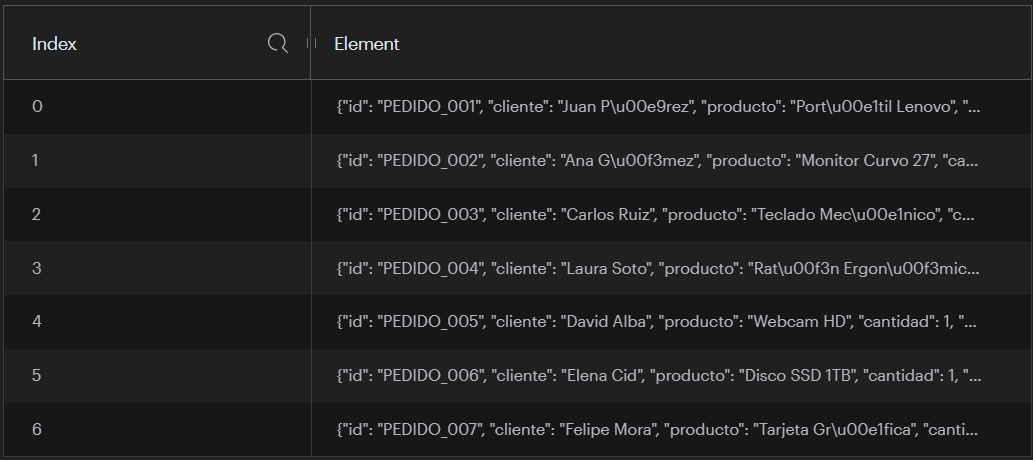

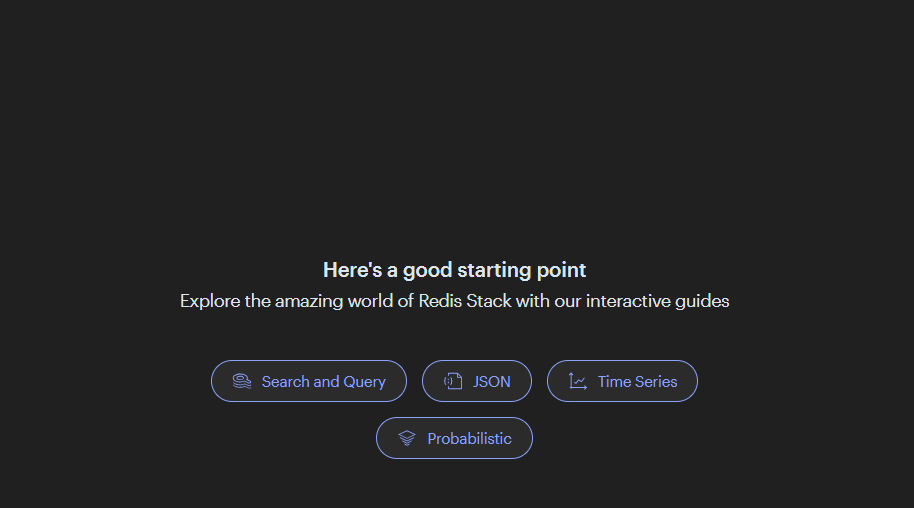

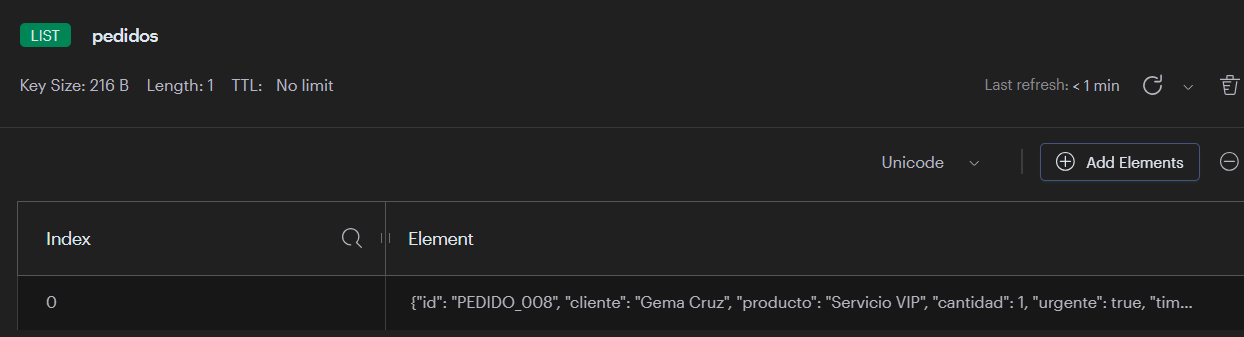

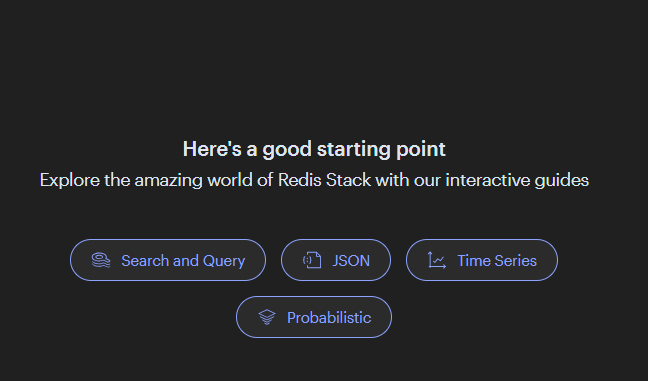